In [5]:
import typing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset


dataset = load_dataset("../data/responses", split="test")

df = dataset.to_pandas()

In [6]:
df = typing.cast(pd.DataFrame, df)
df.sort_values(by="model").groupby(["model", "lang"])["input_tokens"].mean()

model                                          lang    
Fastweb/FastwebMIIA-7B                         English     21.048889
                                               Friulian    29.928889
                                               Italian     21.524444
                                               Ligurian    30.128889
                                               Lombard     27.811111
                                               Sicilian    29.386667
                                               Venetian    27.206667
Qwen/Qwen3-8B                                  English     22.268889
                                               Friulian    30.800000
                                               Italian     27.728889
                                               Ligurian    32.006667
                                               Lombard     29.788889
                                               Sicilian    32.115556
                                               

In [7]:
df["avg_output_tokens"] = df["output_tokens"].map(lambda x: x[0])
df.groupby(["model", "lang"])["avg_output_tokens"].mean()

model                                          lang    
Fastweb/FastwebMIIA-7B                         English     134.902222
                                               Friulian    267.691111
                                               Italian     143.266667
                                               Ligurian    254.040000
                                               Lombard     228.204444
                                               Sicilian    191.046667
                                               Venetian    268.702222
Qwen/Qwen3-8B                                  English     358.406667
                                               Friulian    427.820000
                                               Italian     554.146667
                                               Ligurian    464.842222
                                               Lombard     504.182222
                                               Sicilian    551.608889
                                  

Text(0.5, 0.98, 'Token Distributions by Language and Model')

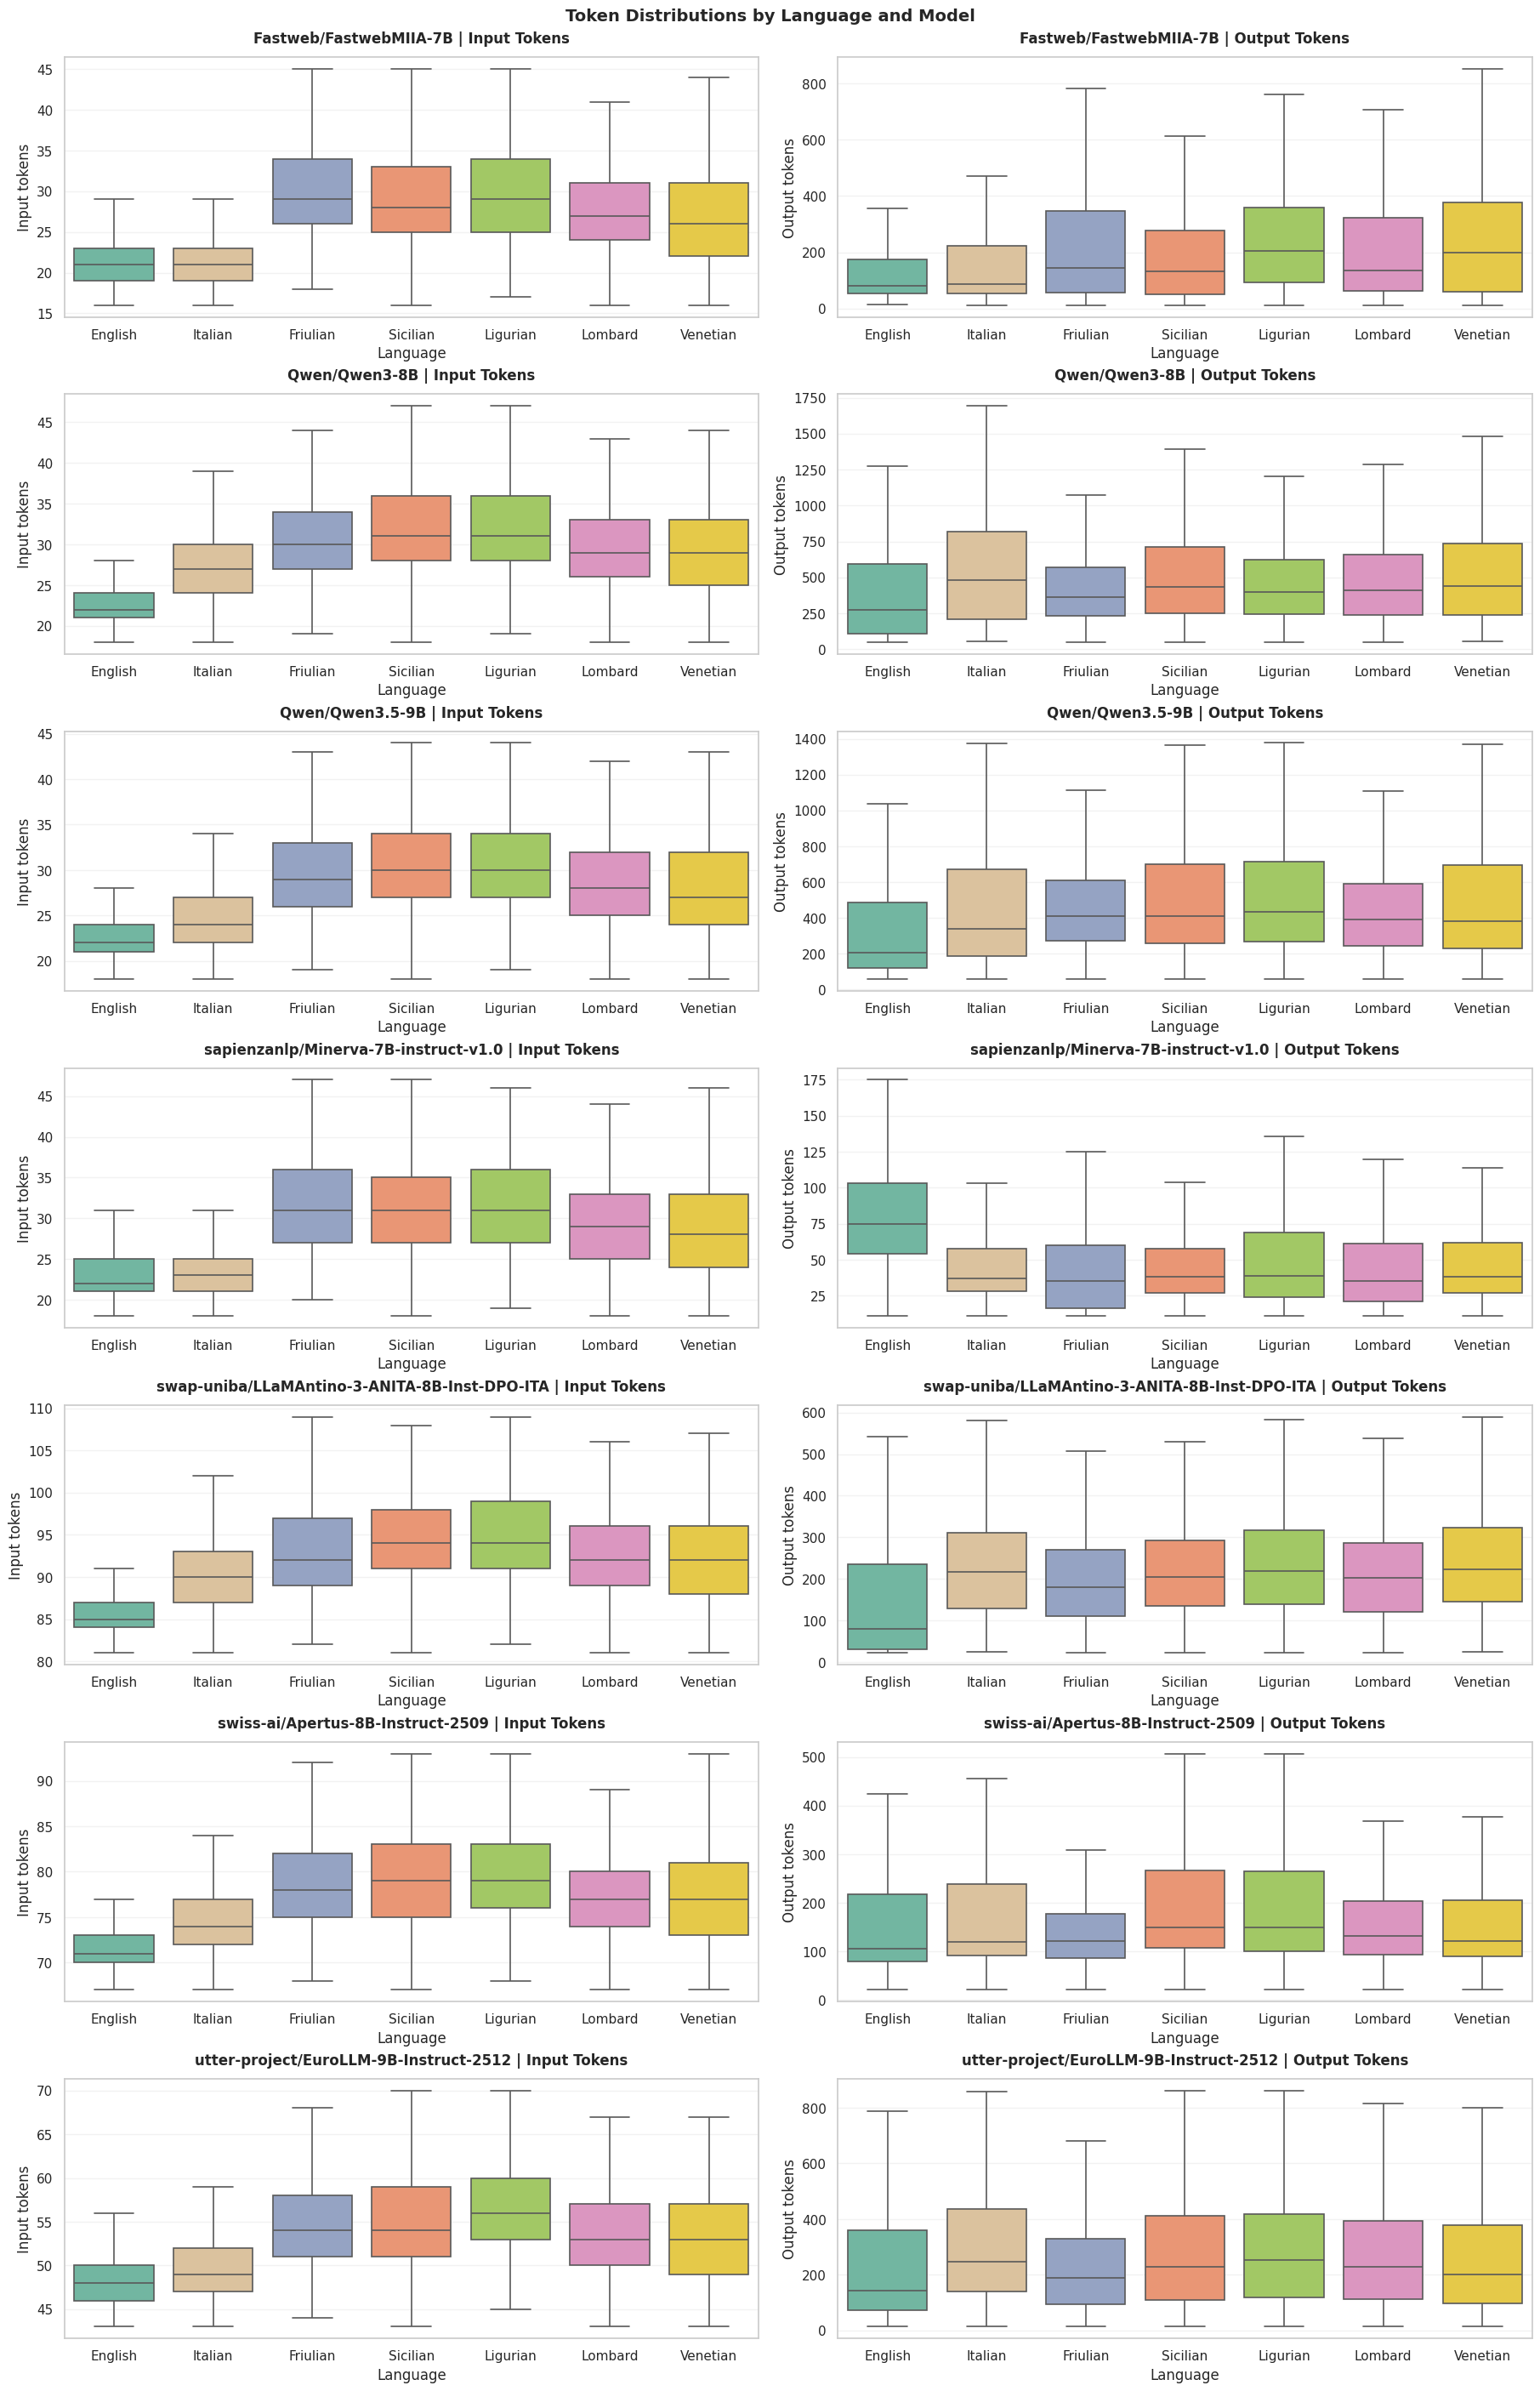

In [8]:
# Build plotting tables
input_df = df[["model", "lang", "input_tokens"]].dropna().copy()

output_df = (
    df[["model", "lang", "output_tokens"]].explode("output_tokens").rename(columns={"output_tokens": "output_token"})
)
output_df["output_token"] = pd.to_numeric(output_df["output_token"], errors="coerce")
output_df = output_df.dropna(subset=["output_token"])

models = sorted(df["model"].dropna().unique())
lang_order = ["English", "Italian", "Friulian", "Sicilian", "Ligurian", "Lombard", "Venetian"]
langs = [lang for lang in lang_order if lang in df["lang"].dropna().unique()]

sns.set_theme(style="whitegrid", context="notebook")
palette = sns.color_palette("Set2", n_colors=len(langs))

n_models = len(models)
fig, axes = plt.subplots(n_models, 2, figsize=(18, 4 * n_models), constrained_layout=True)
if n_models == 1:
    axes = np.array([axes])

for i, model_name in enumerate(models):
    model_input = input_df[input_df["model"] == model_name].copy()
    model_output = output_df[output_df["model"] == model_name].copy()

    # Filter only for plotting to reduce the visual impact of extreme values.
    in_low, in_high = model_input["input_tokens"].quantile([0.01, 0.99])
    out_low, out_high = model_output["output_token"].quantile([0.01, 0.99])
    model_input = model_input[model_input["input_tokens"].between(in_low, in_high)]
    model_output = model_output[model_output["output_token"].between(out_low, out_high)]

    ax_in = axes[i, 0]
    sns.boxplot(
        data=model_input,
        x="lang",
        y="input_tokens",
        order=langs,
        hue="lang",
        palette=palette,
        dodge=False,
        showfliers=False,
        linewidth=1.2,
        ax=ax_in,
    )
    leg = ax_in.get_legend()
    if leg is not None:
        leg.remove()
    ax_in.set_title(f"{model_name} | Input Tokens", pad=12, fontweight="bold")
    ax_in.set_xlabel("Language")
    ax_in.set_ylabel("Input tokens")
    # ax_in.tick_params(axis="x", rotation=30)
    ax_in.grid(axis="y", alpha=0.25)

    ax_out = axes[i, 1]
    sns.boxplot(
        data=model_output,
        x="lang",
        y="output_token",
        order=langs,
        hue="lang",
        palette=palette,
        dodge=False,
        showfliers=False,
        linewidth=1.2,
        ax=ax_out,
    )
    leg = ax_out.get_legend()
    if leg is not None:
        leg.remove()
    ax_out.set_title(f"{model_name} | Output Tokens", pad=12, fontweight="bold")
    ax_out.set_xlabel("Language")
    ax_out.set_ylabel("Output tokens")
    # ax_out.tick_params(axis="x", rotation=30)
    ax_out.grid(axis="y", alpha=0.25)

fig.suptitle("Token Distributions by Language and Model", fontsize=14, fontweight="bold")